<a href="https://colab.research.google.com/github/Akash14-09/Machine_Learning/blob/main/Relu_Zero_intialization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('/content/Social_Network_Ads.csv')

In [ ]:
df

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0
...,...,...,...,...,...
395,15691863,Female,46,41000,1
396,15706071,Male,51,23000,1
397,15654296,Female,50,20000,1
398,15755018,Male,36,33000,0


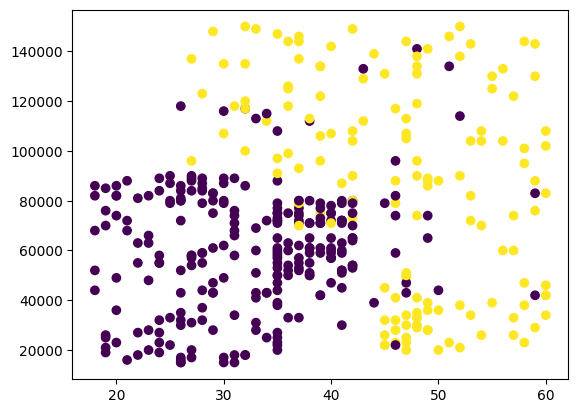

In [ ]:
plt.scatter(df['Age'] , df['EstimatedSalary'] , c=  df['Purchased'])

In [ ]:
X = df.iloc[: , 0:2].values
y = df.iloc[: , -1].values

In [ ]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense

In [ ]:
model = Sequential()

model.add(Dense(10 , activation = 'tanh' , input_dim = 2))
model.add(Dense(1, activation='sigmoid'))
model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 41 (164.00 B)

 Trainable params: 41 (164.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#setting parameters equals to zero
model.get_weights()

[array([[-0.62689793,  0.6087603 , -0.2478582 ,  0.6500657 , -0.30362538,
          0.1841991 , -0.3122382 ,  0.02502209,  0.49528366,  0.601558  ],
        [ 0.14080572, -0.0290218 , -0.49187565,  0.4328249 , -0.3523866 ,
         -0.06635416,  0.01889914,  0.34799773,  0.21725065, -0.29327446]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[ 0.25442612],
        [-0.05298096],
        [ 0.5075138 ],
        [ 0.38358623],
        [-0.42493826],
        [-0.416675  ],
        [ 0.24258095],
        [ 0.32113963],
        [-0.64973295],
        [ 0.27073163]], dtype=float32),
 array([0.], dtype=float32)]

In [ ]:
intial_weights = model.get_weights()

setting all weights and biases equals to zero then nothing will change further

In [ ]:
intial_weights[0] = np.zeros(model.get_weights()[0].shape)
intial_weights[1] = np.zeros(model.get_weights()[1].shape)
intial_weights[2] = np.zeros(model.get_weights()[2].shape)
intial_weights[3] = np.zeros(model.get_weights()[3].shape)

In [ ]:
model.set_weights(intial_weights)

In [ ]:
model.get_weights()

[array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]], dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.]], dtype=float32),
 array([0.], dtype=float32)]

In [ ]:
model.compile(loss = 'binary_crossentropy' , optimizer= 'adam' , metrics = ['accuracy'])

In [ ]:
from sklearn.preprocessing import StandardScaler

# Correctly select 'Age' (index 2) and 'EstimatedSalary' (index 3)
X = df.iloc[:, 2:4].values

# Scale the features for better gradient descent performance
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Re-compile and fit the model
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
history = model.fit(X, y, epochs=100, validation_split=0.2)

Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.7125 - loss: 0.6922 - val_accuracy: 0.3625 - val_loss: 0.6944
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7125 - loss: 0.6903 - val_accuracy: 0.3625 - val_loss: 0.6958
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7125 - loss: 0.6882 - val_accuracy: 0.3625 - val_loss: 0.6971
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7125 - loss: 0.6863 - val_accuracy: 0.3625 - val_loss: 0.6984
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7125 - loss: 0.6846 - val_accuracy: 0.3625 - val_loss: 0.6998
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7125 - loss: 0.6828 - val_accuracy: 0.3625 - val_loss: 0.7013
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7125 - loss: 0.6808 - val_accuracy: 0.3625 - val_loss: 0.7026
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7125 - loss: 0.6791 - val_accuracy: 0.3625 - 

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 6s 666us/step


<Axes: >

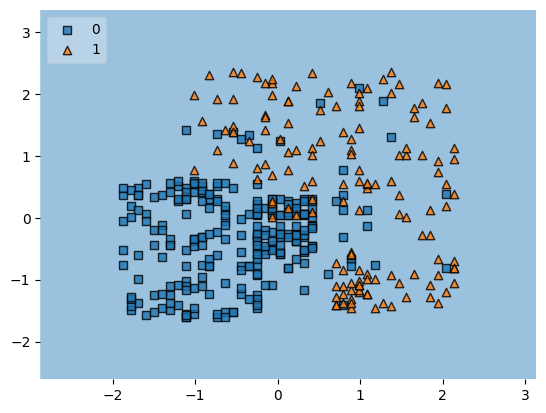

In [ ]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X,y.astype('int'), clf=model, legend=2)